In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
!pip install ultralytics --no-deps -q
import os, shutil, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image, ImageFilter, ImageEnhance
from collections import defaultdict

# Machine Learning & Metrics
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
from torch.nn.parallel import DataParallel
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms
import torchvision.transforms.functional as TF

# Computer Vision
from ultralytics import YOLO

# --- Configuration & Reproducibility ---
warnings.filterwarnings('ignore')
SEED = 42
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

# --- Dual T4 GPU Verification ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpu_count = torch.cuda.device_count()

print(f'✅ All imports done')
print(f'🚀 Using device: {device}')
if gpu_count > 1:
    print(f'🔥 Dual GPU Mode Active: {gpu_count} GPUs detected')
    for i in range(gpu_count):
        print(f'   - GPU {i}: {torch.cuda.get_device_name(i)}')
else:
    print(f'⚠️ Only {gpu_count} GPU detected. Check Kaggle settings if you expected T4*2.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.8 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ All imports done
🚀 Using device: cuda
🔥 Dual GPU Mode Active: 2 GPUs detected
   - GPU 0: Tesla T4
   - GPU 1: Tesla T4


In [ ]:
# ── Dataset paths ─────────────────────────────────────────────────────────────
DATA_PATH = '/kaggle/input/airbus-ship-detection/train_v2/'
CSV_PATH  = '/kaggle/input/airbus-ship-detection/train_ship_segmentations_v2.csv'

if not os.path.exists(CSV_PATH):
    DATA_PATH = '/kaggle/input/competitions/airbus-ship-detection/train_v2/'
    CSV_PATH  = '/kaggle/input/competitions/airbus-ship-detection/train_ship_segmentations_v2.csv'

assert os.path.exists(CSV_PATH),  f'CSV not found: {CSV_PATH}'
assert os.path.exists(DATA_PATH), f'Images not found: {DATA_PATH}'
print(f'CSV   : {CSV_PATH}')
print(f'Images: {DATA_PATH}')


BASE         = '/kaggle/working/yolo_dataset'
YOLO_WEIGHTS = '/kaggle/working/runs/detect/train/weights/best.pt'
MODEL_PATH   = '/kaggle/working/best_model.pth'
CKPT_PATH    = '/kaggle/working/checkpoint.pth'

N_CLUSTERS   = 3       
SAMPLE_SIZE  = 4000
MIN_SHIPS    = 3
IMAGE_SIZE   = 224
BATCH_SIZE   = 32
EPOCHS       = 15
LR           = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.3

SHIP_MASK_SCALE  = 1.0   
CAPACITY_DIVISOR = 5000  
MIN_CAPACITY     = 1     

BLUR_THRESHOLD   = 100.0  
RAIN_SAT_LOW     = 30     
SNOW_VAL_HIGH    = 200    

DEVICE = torch.device('cuda')
LEVEL_NAMES = ['Low', 'Medium', 'High']
PALETTE     = ['#2ecc71', '#f39c12', '#e74c3c']

print(f'\n✅ Config ready | Device: {DEVICE}')

CSV   : /kaggle/input/competitions/airbus-ship-detection/train_ship_segmentations_v2.csv
Images: /kaggle/input/competitions/airbus-ship-detection/train_v2/

✅ Config ready | Device: cuda


In [ ]:
def rle_decode(mask_rle, shape=(768, 768)):
    
    s = mask_rle.split()
    starts  = np.asarray(s[0::2], dtype=int) - 1
    lengths = np.asarray(s[1::2], dtype=int)
    ends    = starts + lengths
    img     = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape).T


def mask_to_bbox(mask):

    ys, xs = np.where(mask == 1)
    if len(xs) == 0:
        return None
    return int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())


def to_yolo(img_w, img_h, xmin, ymin, xmax, ymax):
    
    cx = (xmin + xmax) / 2.0 / img_w
    cy = (ymin + ymax) / 2.0 / img_h
    bw = (xmax - xmin) / img_w
    bh = (ymax - ymin) / img_h
    return cx, cy, bw, bh


print('✅ Utility functions defined')

✅ Utility functions defined


In [6]:
df_raw   = pd.read_csv(CSV_PATH)
df_masks = df_raw[df_raw['EncodedPixels'].notna()].copy()

ship_counts = (
    df_masks.groupby('ImageId')
    .size()
    .reset_index(name='ship_count')
)
ship_counts = ship_counts[ship_counts['ship_count'] >= MIN_SHIPS]
ship_counts = ship_counts.sample(SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)

print(f'Images selected : {len(ship_counts)}')
print(ship_counts['ship_count'].describe().round(2))

Images selected : 4000
count    4000.00
mean        5.06
std         2.67
min         3.00
25%         3.00
50%         4.00
75%         6.00
max        15.00
Name: ship_count, dtype: float64


Estimating port sizes from mask unions...

Port stats (n=4000):
       ship_count  port_area_px  port_capacity  congestion_ratio
count     4000.00       4000.00        4000.00           4000.00
mean         5.06     153553.64          30.74              0.67
std          2.67     130164.40          26.00              1.22
min          3.00        238.00           1.00              0.03
25%          3.00      40020.00           8.00              0.10
50%          4.00     122537.00          24.51              0.19
75%          6.00     237105.25          47.42              0.54
max         15.00     566813.00         113.36             12.00


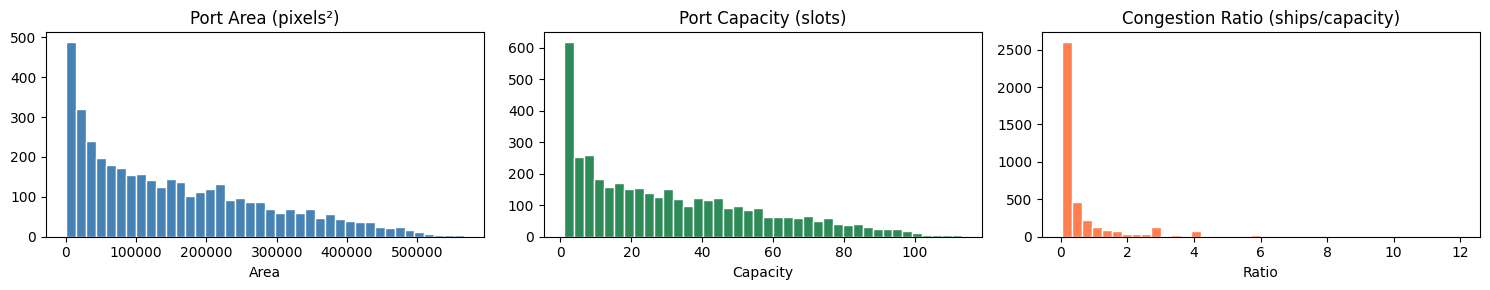

In [ ]:
port_stats = []
selected_ids = set(ship_counts['ImageId'])

print('Estimating port sizes from mask unions...')
for img_id, group in df_masks[df_masks['ImageId'].isin(selected_ids)].groupby('ImageId'):
    union_mask  = np.zeros((768, 768), dtype=np.uint8)
    bbox_list   = []

    for rle in group['EncodedPixels']:
        mask = rle_decode(rle)
        union_mask = np.maximum(union_mask, mask)   
        bbox = mask_to_bbox(mask)
        if bbox is not None:
            bbox_list.append(bbox)

    bbox_union = mask_to_bbox(union_mask)
    if bbox_union is not None:
        xmin, ymin, xmax, ymax = bbox_union
        port_area = max(1, (xmax - xmin) * (ymax - ymin))  
    else:
        port_area = 1

    port_capacity    = max(MIN_CAPACITY, port_area / CAPACITY_DIVISOR)
    n_ships          = len(group)
    congestion_ratio = n_ships / port_capacity

    port_stats.append({
        'ImageId'          : img_id,
        'ship_count'       : n_ships,
        'port_area_px'     : port_area,
        'port_capacity'    : round(port_capacity, 2),
        'congestion_ratio' : round(congestion_ratio, 4),
        'bbox_records'     : bbox_list
    })

port_df = pd.DataFrame(port_stats)
print(f'\nPort stats (n={len(port_df)}):')
print(port_df[['ship_count','port_area_px','port_capacity','congestion_ratio']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
axes[0].hist(port_df['port_area_px'],      bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Port Area (pixels²)');   axes[0].set_xlabel('Area')
axes[1].hist(port_df['port_capacity'],     bins=40, color='seagreen',  edgecolor='white')
axes[1].set_title('Port Capacity (slots)'); axes[1].set_xlabel('Capacity')
axes[2].hist(port_df['congestion_ratio'],  bins=40, color='coral',     edgecolor='white')
axes[2].set_title('Congestion Ratio (ships/capacity)'); axes[2].set_xlabel('Ratio')
plt.tight_layout(); plt.show()

Balanced congestion clusters (quantile-based):
  Level 0 (Low   ): ratio 0.028–0.267  (n=2400)
  Level 1 (Medium): ratio 0.267–0.803  (n=800)
  Level 2 (High  ): ratio 0.804–12.000  (n=800)


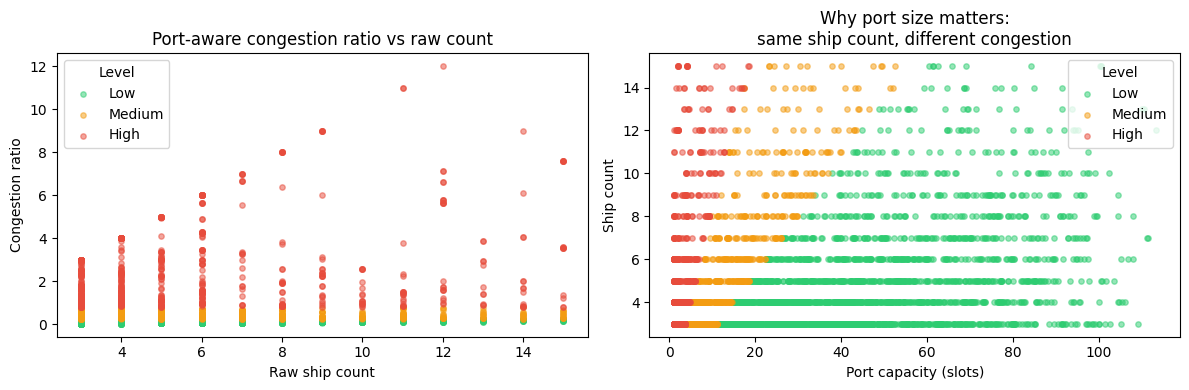

In [ ]:
X_ratio = port_df[['congestion_ratio']].values.astype(float)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=20)
raw_labels = kmeans.fit_predict(X_ratio)
centers = kmeans.cluster_centers_.flatten()
order   = np.argsort(centers)
remap   = {old: new for new, old in enumerate(order)}

ratios = port_df['congestion_ratio'].values
low_thresh  = np.percentile(ratios, 60)   
high_thresh = np.percentile(ratios, 80)   
                                        

def quantile_label(r):
    if r <= low_thresh:
        return 0   # Low
    elif r <= high_thresh:
        return 1   # Medium
    else:
        return 2   # High

port_df['congestion'] = port_df['congestion_ratio'].apply(quantile_label)

print('Balanced congestion clusters (quantile-based):')
for lvl in range(N_CLUSTERS):
    sub = port_df[port_df['congestion'] == lvl]
    print(f'  Level {lvl} ({LEVEL_NAMES[lvl]:6s}): '
          f'ratio {sub.congestion_ratio.min():.3f}–{sub.congestion_ratio.max():.3f}  '
          f'(n={len(sub)})')

# ── keep the scatter plots exactly as before ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for lvl in range(N_CLUSTERS):
    sub = port_df[port_df['congestion'] == lvl]
    axes[0].scatter(sub['ship_count'],    sub['congestion_ratio'],
                    c=PALETTE[lvl], alpha=0.5, s=15, label=LEVEL_NAMES[lvl])
    axes[1].scatter(sub['port_capacity'], sub['ship_count'],
                    c=PALETTE[lvl], alpha=0.5, s=15, label=LEVEL_NAMES[lvl])

axes[0].set_xlabel('Raw ship count'); axes[0].set_ylabel('Congestion ratio')
axes[0].set_title('Port-aware congestion ratio vs raw count')
axes[0].legend(title='Level')
axes[1].set_xlabel('Port capacity (slots)'); axes[1].set_ylabel('Ship count')
axes[1].set_title('Why port size matters:\nsame ship count, different congestion')
axes[1].legend(title='Level')
plt.tight_layout(); plt.show()


Unloading time by congestion level:
             count  mean   std   min   25%   50%    75%    max
congestion                                                    
0           2400.0  1.47  0.38  1.00  1.12  1.42   1.73   3.08
1            800.0  3.91  0.43  2.63  3.62  3.89   4.23   5.21
2            800.0  9.25  1.23  7.09  8.24  8.98  10.15  13.99


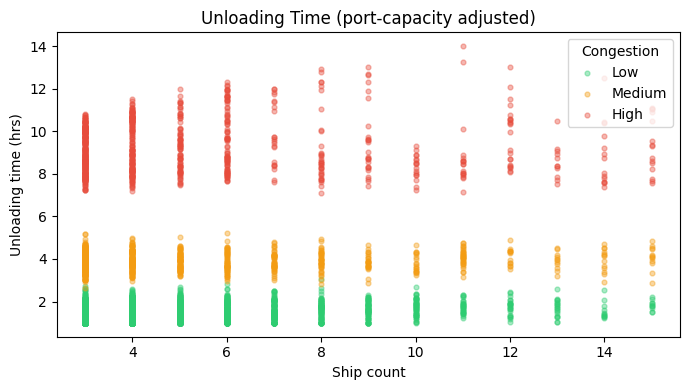

In [9]:
CONGESTION_OVERHEAD = {0: 0.5, 1: 2.5, 2: 6.0}  # hours added per level
BASE_HRS_PER_SHIP   = 2.0

def compute_unloading_time(ship_count, port_capacity, congestion_level, noise_std=0.4):
    """
    Unloading time (hours).

    Formula:
      base     = BASE_HRS * log(1+ships)          <- sub-linear throughput
      capacity = base / log(1+capacity)            <- larger port = faster
      overhead = CONGESTION_OVERHEAD[level]        <- queue wait time
      + Gaussian noise
    """
    base     = BASE_HRS_PER_SHIP * np.log1p(ship_count)
    cap_adj  = base / np.log1p(max(1, port_capacity))  # capacity discount
    overhead = CONGESTION_OVERHEAD[congestion_level]
    noise    = np.random.normal(0, noise_std)
    return float(np.clip(cap_adj + overhead + noise, 1.0, None))

np.random.seed(SEED)
port_df['unload_time'] = port_df.apply(
    lambda r: compute_unloading_time(r['ship_count'], r['port_capacity'], r['congestion']),
    axis=1
)

print('Unloading time by congestion level:')
print(port_df.groupby('congestion')['unload_time'].describe().round(2))

fig, ax = plt.subplots(figsize=(7, 4))
for lvl in range(N_CLUSTERS):
    sub = port_df[port_df['congestion'] == lvl]
    ax.scatter(sub['ship_count'], sub['unload_time'],
               c=PALETTE[lvl], alpha=0.4, s=12, label=LEVEL_NAMES[lvl])
ax.set_xlabel('Ship count'); ax.set_ylabel('Unloading time (hrs)')
ax.set_title('Unloading Time (port-capacity adjusted)')
ax.legend(title='Congestion'); plt.tight_layout(); plt.show()

In [10]:
bbox_records = []
for _, row in port_df.iterrows():
    for bbox in row['bbox_records']:
        bbox_records.append({
            'image_id': row['ImageId'],
            'xmin': bbox[0], 'ymin': bbox[1],
            'xmax': bbox[2], 'ymax': bbox[3]
        })

bbox_df = pd.DataFrame(bbox_records)
print(f'Total bounding boxes: {len(bbox_df):,}')

Total bounding boxes: 20,258


In [11]:
for split in ['train', 'val']:
    os.makedirs(f'{BASE}/images/{split}', exist_ok=True)
    os.makedirs(f'{BASE}/labels/{split}', exist_ok=True)

train_ids, val_ids = train_test_split(
    port_df['ImageId'].tolist(), test_size=0.2, random_state=SEED
)
print(f'YOLO train: {len(train_ids)} | val: {len(val_ids)}')

YOLO train: 3200 | val: 800


In [12]:
def build_yolo_split(image_ids, split):
    skipped = 0
    for img_id in image_ids:
        src = os.path.join(DATA_PATH, img_id)
        if not os.path.exists(src):
            skipped += 1; continue

        boxes = bbox_df[bbox_df['image_id'] == img_id]
        label_path = f'{BASE}/labels/{split}/{img_id.replace(".jpg",".txt")}'
        with open(label_path, 'w') as f:
            for _, row in boxes.iterrows():
                cx, cy, bw, bh = to_yolo(768, 768, row.xmin, row.ymin, row.xmax, row.ymax)
                if bw > 0 and bh > 0:
                    f.write(f'0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n')
        shutil.copy(src, f'{BASE}/images/{split}/{img_id}')
    print(f'  [{split}] done | skipped {skipped} missing')

build_yolo_split(train_ids, 'train')
build_yolo_split(val_ids,   'val')

  [train] done | skipped 0 missing
  [val] done | skipped 0 missing


In [13]:
yaml_str = f"""path: {BASE}
train: images/train
val:   images/val
nc: 1
names:
  0: ship
"""
with open(f'{BASE}/dataset.yaml', 'w') as f:
    f.write(yaml_str)
print('✅ dataset.yaml\n', yaml_str)

✅ dataset.yaml
 path: /kaggle/working/yolo_dataset
train: images/train
val:   images/val
nc: 1
names:
  0: ship



In [16]:
yolo = YOLO('yolov8n.pt')
yolo.train(
    data     = f'{BASE}/dataset.yaml',
    epochs   = 20,
    imgsz    = 640,
    batch    = 16,
    device   = 0,
    patience = 5,
    name     = 'train',
    exist_ok = True,
    verbose  = True
)
print(f'✅ YOLOv8 done | weights: {YOLO_WEIGHTS}')

Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, persp

In [17]:
detector  = YOLO(YOLO_WEIGHTS)
val_dir   = f'{BASE}/images/val'

results     = detector.predict(source=val_dir, save=False, verbose=False)
pred_counts = [len(r.boxes) for r in results]
img_names   = [os.path.basename(r.path) for r in results]

print(f'Val images: {len(img_names)} | counts min={min(pred_counts)} max={max(pred_counts)} mean={np.mean(pred_counts):.1f}')

Val images: 800 | counts min=0 max=20 mean=4.9


In [18]:
cap_lookup = port_df.set_index('ImageId')['port_capacity'].to_dict()

df_val_list = []
for img_name, n_ships in zip(img_names, pred_counts):
    cap = cap_lookup.get(img_name, max(1, n_ships / 1.5))
    ratio = n_ships / max(1, cap)

    # ── NEW: use same quantile thresholds as Cell 6 ──
    if ratio <= low_thresh:
        cong_level = 0
    elif ratio <= high_thresh:
        cong_level = 1
    else:
        cong_level = 2

    unload = compute_unloading_time(n_ships, cap, cong_level)
    df_val_list.append({
        'image'      : img_name,
        'ships'      : n_ships,
        'port_cap'   : cap,
        'cong_ratio' : ratio,
        'congestion' : cong_level,
        'unload_time': unload
    })

df_val = pd.DataFrame(df_val_list)
np.random.seed(SEED)
print(df_val.head(8).to_string(index=False))
print('\nCongestion distribution (val):')
for lvl, cnt in df_val['congestion'].value_counts().sort_index().items():
    print(f'  Level {lvl} ({LEVEL_NAMES[lvl]}): {cnt}')

        image  ships  port_cap  cong_ratio  congestion  unload_time
00abc623a.jpg      3     33.29    0.090117           0     1.989978
00ee04562.jpg      6     27.22    0.220426           0     1.825268
012d9c145.jpg      3     40.21    0.074608           0     1.637079
013b9540b.jpg      4     51.95    0.076997           0     2.207290
015fb893d.jpg      5     34.02    0.146972           0     2.254785
018054283.jpg      3     31.28    0.095908           0     1.000000
01c934c85.jpg      4      1.00    4.000000           2    11.023892
01e0fce2c.jpg      3     48.94    0.061300           0     1.148410

Congestion distribution (val):
  Level 0 (Low): 512
  Level 1 (Medium): 165
  Level 2 (High): 123


In [ ]:
import cv2

def detect_weather(img_pil):
    """
    Classify image weather condition.
    Returns: 'clear' | 'rainy' | 'snowy' | 'foggy'
    """
    img_np  = np.array(img_pil.convert('RGB'))
    img_hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

    sat_mean = float(img_hsv[:, :, 1].mean())   
    val_mean = float(img_hsv[:, :, 2].mean())   

    gray       = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    blur_score = float(cv2.Laplacian(gray, cv2.CV_64F).var())

    if val_mean > SNOW_VAL_HIGH and sat_mean < RAIN_SAT_LOW:
        return 'snowy',  sat_mean, val_mean, blur_score
    elif sat_mean < RAIN_SAT_LOW:
        return 'rainy',  sat_mean, val_mean, blur_score
    elif blur_score < BLUR_THRESHOLD:
        return 'foggy',  sat_mean, val_mean, blur_score
    else:
        return 'clear',  sat_mean, val_mean, blur_score


class WeatherRobustTransform:
    """
    Applies targeted pre-processing based on detected weather,
    then standard augmentation + normalisation.

    Strategy:
      rainy/foggy → gamma correction (brighten) + contrast boost
      snowy       → brightness normalisation + contrast equalization
      clear       → standard augmentation

    The key idea: correct the image BEFORE the network sees it,
    so the model never learns weather-specific biases.
    """

    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]

    def __init__(self, is_train=True):
        self.is_train = is_train

        # Standard augmentation applied after weather correction
        self.base_aug = transforms.Compose([
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomVerticalFlip(0.3),
            transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
        ]) if is_train else transforms.Compose([])

        self.to_tensor_norm = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(self.IMAGENET_MEAN, self.IMAGENET_STD),
        ])

    def correct_rain(self, img):
        """Brighten dark rain-haze images via gamma correction."""
        img_np = np.array(img).astype(np.float32) / 255.0
        gamma  = 0.7    # < 1.0 brightens the image
        img_np = np.power(img_np, gamma)
        img_np = np.clip(img_np * 255, 0, 255).astype(np.uint8)
        # Boost contrast to restore washed-out colours
        img_out = Image.fromarray(img_np)
        return ImageEnhance.Contrast(img_out).enhance(1.4)

    def correct_snow(self, img):
        """Reduce overexposure and boost contrast for snowy images."""
        img_np = np.array(img).astype(np.float32)
        # Clip the bright tail and rescale
        p99    = np.percentile(img_np, 99)
        img_np = np.clip(img_np, 0, p99) / p99 * 255
        img_out = Image.fromarray(img_np.astype(np.uint8))
        return ImageEnhance.Contrast(img_out).enhance(1.3)

    def correct_foggy(self, img):
        """Unsharp mask to recover ship edges lost in fog."""
        return img.filter(ImageFilter.UnsharpMask(radius=2, percent=120, threshold=3))

    def __call__(self, img):
        weather, *_ = detect_weather(img)

        # Step 1: weather-specific correction
        if weather == 'rainy':
            img = self.correct_rain(img)
        elif weather == 'snowy':
            img = self.correct_snow(img)
        elif weather == 'foggy':
            img = self.correct_foggy(img)
        # clear: no correction needed

        # Step 2: standard augmentation (train only)
        if self.is_train:
            img = self.base_aug(img)

        # Step 3: resize → tensor → normalise
        return self.to_tensor_norm(img)


print('✅ WeatherRobustTransform defined')

✅ WeatherRobustTransform defined


Weather distribution in val set (first 200 images):
  foggy   : 142
  clear   : 57
  rainy   : 13


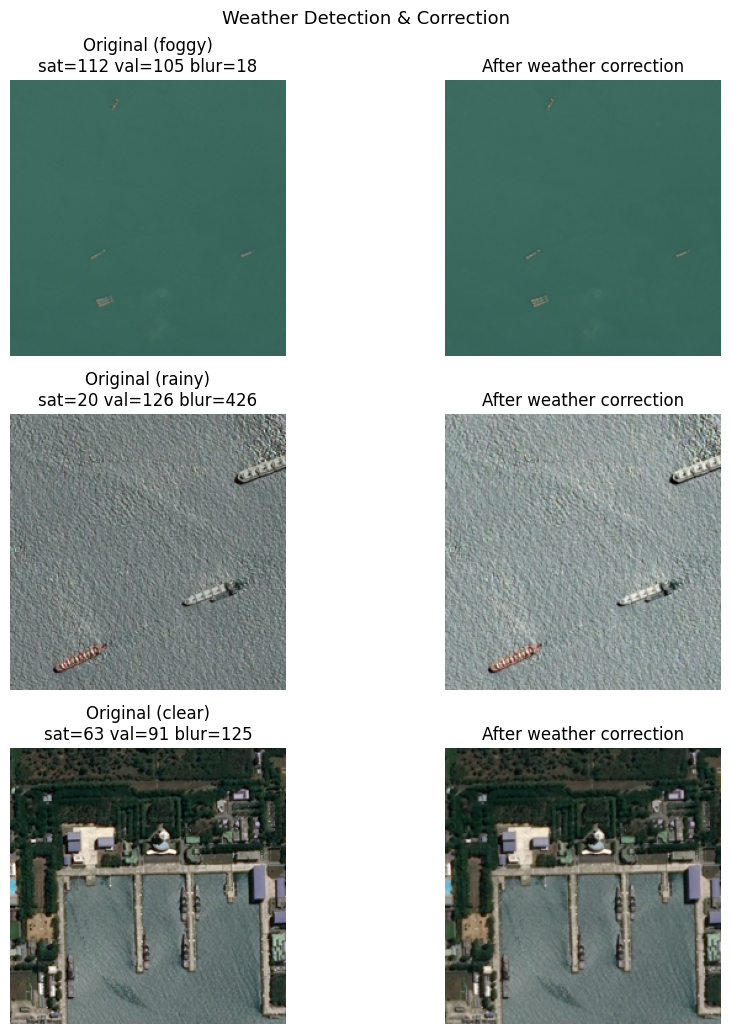

In [20]:
sample_images = [f for f in os.listdir(val_dir) if f.endswith('.jpg')][:12]
weather_counts = defaultdict(int)
weather_examples = {}

for fname in sample_images:
    img  = Image.open(os.path.join(val_dir, fname)).convert('RGB')
    wtype, sat, val, blur = detect_weather(img)
    weather_counts[wtype] += 1
    if wtype not in weather_examples:
        weather_examples[wtype] = (fname, img, sat, val, blur)

# Scan more images to get better weather stats
all_val = [f for f in os.listdir(val_dir) if f.endswith('.jpg')]
for fname in all_val[:200]:
    img   = Image.open(os.path.join(val_dir, fname)).convert('RGB')
    wtype, *_ = detect_weather(img)
    weather_counts[wtype] += 1

print('Weather distribution in val set (first 200 images):')
for wtype, cnt in sorted(weather_counts.items(), key=lambda x: -x[1]):
    print(f'  {wtype:8s}: {cnt}')

# Show before/after weather correction
transform_robust = WeatherRobustTransform(is_train=False)

if weather_examples:
    n_ex = min(len(weather_examples), 4)
    fig, axes = plt.subplots(n_ex, 2, figsize=(10, 3.5 * n_ex))
    if n_ex == 1: axes = [axes]

    for i, (wtype, (fname, img, sat, val_, blur)) in enumerate(list(weather_examples.items())[:n_ex]):
        axes[i][0].imshow(img.resize((224, 224)))
        axes[i][0].set_title(f'Original ({wtype})\nsat={sat:.0f} val={val_:.0f} blur={blur:.0f}')
        axes[i][0].axis('off')

        # Show corrected image by inverting normalisation
        tensor = transform_robust(img.copy())
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        corrected = (tensor * std + mean).permute(1,2,0).clamp(0,1).numpy()
        axes[i][1].imshow(corrected)
        axes[i][1].set_title(f'After weather correction')
        axes[i][1].axis('off')

    plt.suptitle('Weather Detection & Correction', fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print('No diverse weather examples in first 12 val images; detection still active during training.')

In [ ]:
class MultiTaskPortNet(nn.Module):
    
    def __init__(self, num_classes=N_CLUSTERS, dropout=DROPOUT):
        super().__init__()

        backbone      = models.resnet18(weights='DEFAULT')
        self.feat_dim = backbone.fc.in_features   # 512
        backbone.fc   = nn.Identity()
        self.backbone = backbone

        fused_dim = self.feat_dim + 1

        self.shared = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )
        self.cls_head = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )
        self.reg_head = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1)
        )

    def forward(self, x, port_cap):
        feats  = self.backbone(x)                             # (B, 512)
        cap_n  = port_cap.unsqueeze(1).float()               # (B, 1)
        fused  = torch.cat([feats, cap_n], dim=1)            # (B, 513)
        shared = self.shared(fused)
        return self.cls_head(shared), self.reg_head(shared)


# Sanity check
_m = MultiTaskPortNet()
_x = torch.randn(4, 3, IMAGE_SIZE, IMAGE_SIZE)
_c_cap = torch.tensor([10.0, 5.0, 20.0, 8.0])
_cls, _reg = _m(_x, _c_cap)
print('✅ MultiTaskPortNet')
print(f'   cls shape : {_cls.shape}  (batch × classes)')
print(f'   reg shape : {_reg.shape}  (batch × 1)')
print(f'   params    : {sum(p.numel() for p in _m.parameters()):,}')
del _m, _x, _c_cap, _cls, _reg

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


✅ MultiTaskPortNet
   cls shape : torch.Size([4, 3])  (batch × classes)
   reg shape : torch.Size([4, 1])  (batch × 1)
   params    : 11,383,108


In [22]:
class PortDataset(Dataset):
    """
    Returns: (image_tensor, port_capacity, congestion_label, unload_time)
    Applies WeatherRobustTransform — automatically detects and corrects
    rain / snow / fog before feeding images to the model.
    """
    def __init__(self, dataframe, image_dir, is_train=True):
        self.df        = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = WeatherRobustTransform(is_train=is_train)
        # Normalise port_capacity to [0,1] range for stable training
        cap_vals       = self.df['port_cap'].values.astype(float)
        self.cap_min   = cap_vals.min()
        self.cap_max   = max(cap_vals.max() - cap_vals.min(), 1.0)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row['image'])

        if not os.path.exists(img_path):
            img_tensor = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        else:
            img = Image.open(img_path).convert('RGB')
            img_tensor = self.transform(img)

        cap_norm    = torch.tensor(
            (float(row['port_cap']) - self.cap_min) / self.cap_max,
            dtype=torch.float32
        )
        congestion  = torch.tensor(int(row['congestion']),   dtype=torch.long)
        unload_time = torch.tensor(float(row['unload_time']), dtype=torch.float32)

        return img_tensor, cap_norm, congestion, unload_time


print('✅ PortDataset defined')

✅ PortDataset defined


In [32]:
from torch.utils.data import WeightedRandomSampler

mt_train_df, mt_val_df = train_test_split(
    df_val, test_size=0.2, random_state=SEED, stratify=df_val['congestion']
)

train_ds = PortDataset(mt_train_df, val_dir, is_train=True)
val_ds   = PortDataset(mt_val_df,   val_dir, is_train=False)

# ── FIXED: WeightedRandomSampler for balanced batches ──────────
# Each sample gets a weight inversely proportional to its class size.
# This ensures every batch contains a mix of all 3 classes.
label_array    = mt_train_df['congestion'].values
sample_counts  = np.bincount(label_array, minlength=N_CLUSTERS)
weight_per_cls = 1.0 / np.maximum(sample_counts, 1)
sample_weights = torch.tensor(
    [weight_per_cls[l] for l in label_array], dtype=torch.float32
)

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

train_loader = DataLoader(
    train_ds,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,        # replaces shuffle=True
    num_workers = 2,
    pin_memory  = True,
    drop_last   = True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

print(f'Multi-task train : {len(train_ds)} | val: {len(val_ds)}')
print(f'Train batches    : {len(train_loader)} | val batches: {len(val_loader)}')
print(f'Class counts     : {sample_counts.tolist()}')
print(f'WeightedRandomSampler active ✅')


Multi-task train : 640 | val: 160
Train batches    : 20 | val batches: 5
Class counts     : [410, 132, 98]
WeightedRandomSampler active ✅


In [24]:
import torch

assert torch.cuda.is_available(), 'Enable GPU: Notebook Settings → Accelerator → GPU T4 x2'

NUM_GPUS = torch.cuda.device_count()
print(f'PyTorch : {torch.__version__}')
print(f'GPUs    : {NUM_GPUS}')

PyTorch : 2.10.0+cu128
GPUs    : 2


In [ ]:
class GradSyncProfiler:
    
    def __init__(self, model):
        self.sync_times  = defaultdict(float)
        self.sync_counts = defaultdict(int)
        self._hooks      = []
        self._attach(model)

    def _attach(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                def make_hook(n):
                    def hook(grad):
                        t0 = time.perf_counter()
                        if grad is not None:
                            _ = grad.sum()   
                        self.sync_times[n]  += time.perf_counter() - t0
                        self.sync_counts[n] += 1
                        return grad
                    return hook
                h = param.register_hook(make_hook(name))
                self._hooks.append(h)

    def top_layers(self, n=5):
        """Return the n layers with highest total sync time."""
        sorted_layers = sorted(self.sync_times.items(), key=lambda x: -x[1])
        return sorted_layers[:n]

    def total_sync_ms(self):
        return sum(self.sync_times.values()) * 1000

    def remove(self):
        for h in self._hooks:
            h.remove()


print('✅ GradSyncProfiler defined')

✅ GradSyncProfiler defined


In [33]:
net = MultiTaskPortNet(num_classes=N_CLUSTERS, dropout=DROPOUT).to(DEVICE)
net = DataParallel(net)    # uses all available GPUs

print(f'✅ DataParallel across {NUM_GPUS} GPU(s)')
print(f'   Trainable params: {sum(p.numel() for p in net.parameters() if p.requires_grad):,}')

# ── FIXED: Mild class-weighted CrossEntropy using sqrt ─────────
# sqrt smoothing prevents overcorrection — all classes stay learnable.
# Raw inverse-frequency was too aggressive (caused Low to collapse to 0).
counts       = np.bincount(mt_train_df['congestion'].values, minlength=N_CLUSTERS)
class_weights = torch.tensor(
    1.0 / np.sqrt(np.maximum(counts / counts.sum(), 1e-6)),
    dtype=torch.float32
).to(DEVICE)
class_weights = class_weights / class_weights.sum() * N_CLUSTERS  # rescale to sum=N

print(f'\n  Class counts in train split : {counts.tolist()}')
print(f'  Class weights (sqrt-scaled) : {class_weights.cpu().numpy().round(3).tolist()}')

ce_loss  = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
mse_loss = nn.MSELoss()

optimizer = torch.optim.AdamW(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# Attach gradient profiler
profiler = GradSyncProfiler(net)
print('✅ GradSyncProfiler attached')


✅ DataParallel across 2 GPU(s)
   Trainable params: 11,383,108

  Class counts in train split : [410, 132, 98]
  Class weights (sqrt-scaled) : [0.6240000128746033, 1.100000023841858, 1.2760000228881836]
✅ GradSyncProfiler attached


In [ ]:
# Rename 'ImageId' to 'image' to match what your PortDataset __getitem__ expects
df_train = df_train.rename(columns={'ImageId': 'image'})
df_val = df_val.rename(columns={'ImageId': 'image'})

print("✅ Image column renamed successfully!")
print("Current columns:", df_train.columns.tolist())

In [ ]:
from sklearn.metrics import f1_score

history = {
    'train_loss': [], 'val_loss': [],
    'val_acc': [],    'val_mae': [],
    'val_macro_f1': [],
    'throughput': [],  'sync_ms': []
}
best_macro_f1 = -1.0          # NEW: save on best macro-F1, not loss

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.perf_counter()

    # ── TRAIN ──────────────────────────────────────────────────
    net.train()
    running_loss = 0.0
    images_seen  = 0

    for imgs, cap, cong, time_ in train_loader:
        imgs  = imgs.to(DEVICE)
        cap   = cap.to(DEVICE)
        cong  = cong.to(DEVICE)
        time_ = time_.to(DEVICE)

        logits, pred_t = net(imgs, cap)

        loss_cls = ce_loss(logits, cong)
        loss_reg = mse_loss(pred_t.squeeze(1), time_)
        loss     = loss_cls + loss_reg

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        images_seen  += imgs.size(0)

    scheduler.step()
    epoch_time  = time.perf_counter() - epoch_start
    throughput  = images_seen / epoch_time
    avg_train   = running_loss / len(train_ds)
    sync_ms_ep  = profiler.total_sync_ms()

    # ── VALIDATE ───────────────────────────────────────────────
    net.eval()
    val_running = 0.0
    all_tc, all_pc, all_tt, all_pt = [], [], [], []

    with torch.no_grad():
        for imgs, cap, cong, time_ in val_loader:
            imgs  = imgs.to(DEVICE)
            cap   = cap.to(DEVICE)
            cong  = cong.to(DEVICE)
            time_ = time_.to(DEVICE)

            logits, pred_t = net(imgs, cap)
            val_running   += (ce_loss(logits, cong) +
                              mse_loss(pred_t.squeeze(1), time_)).item() * imgs.size(0)

            all_tc.extend(cong.cpu().numpy())
            all_pc.extend(logits.argmax(1).cpu().numpy())
            all_tt.extend(time_.cpu().numpy())
            all_pt.extend(pred_t.squeeze(1).cpu().numpy())

    avg_val    = val_running / len(val_ds)
    val_acc    = np.mean(np.array(all_tc) == np.array(all_pc))
    val_mae    = mean_absolute_error(all_tt, all_pt)
    macro_f1   = f1_score(all_tc, all_pc, average='macro', zero_division=0)  # NEW

    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)
    history['val_acc'].append(val_acc)
    history['val_mae'].append(val_mae)
    history['val_macro_f1'].append(macro_f1)
    history['throughput'].append(throughput)
    history['sync_ms'].append(sync_ms_ep)

    star = ''
    if macro_f1 > best_macro_f1:          # save on macro-F1
        best_macro_f1 = macro_f1
        torch.save(net.state_dict(), MODEL_PATH)
        star = '  ★'

    print(f'Ep {epoch:02d}/{EPOCHS}  train={avg_train:.4f}  val={avg_val:.4f}  '
          f'acc={val_acc:.3f}  macro-F1={macro_f1:.3f}  MAE={val_mae:.2f}h  '
          f'{throughput:.0f} img/s  sync={sync_ms_ep:.1f}ms{star}')

print('\n✅ Training complete')

  DATAPARALLEL / DDP PROFILING REPORT

  GPUs used          : 2
  Avg throughput     : 36.0 images/sec
  Peak throughput    : 36.6 images/sec
  Total grad sync    : 3148.6 ms (across all epochs)
  Avg sync per epoch : 209.9 ms

  Top 5 layers by gradient sync time:
    module.backbone.conv1.weight                               16.43 ms  (300 calls)
    module.backbone.layer3.0.conv1.weight                       8.76 ms  (300 calls)
    module.shared.0.weight                                      7.14 ms  (300 calls)
    module.backbone.layer2.0.conv2.weight                       6.89 ms  (300 calls)
    module.backbone.bn1.bias                                    6.89 ms  (300 calls)


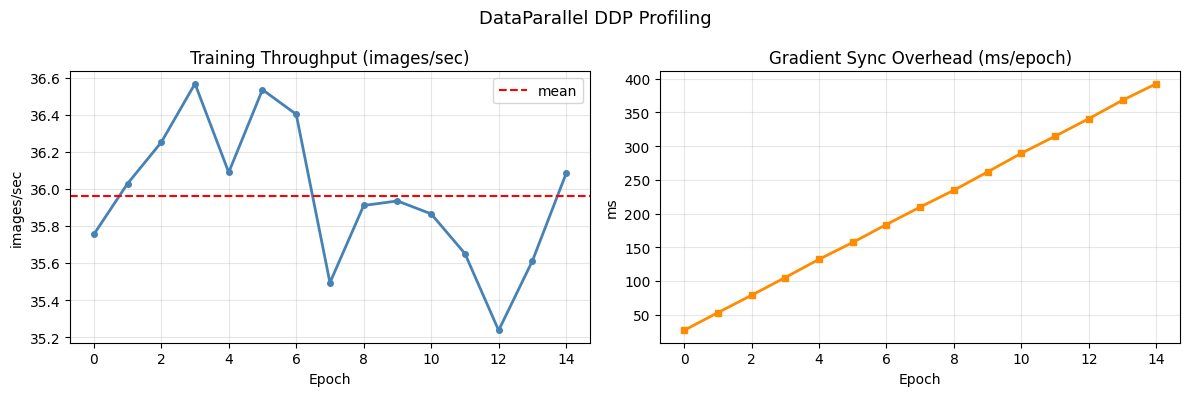


  Profiler hooks removed.


In [35]:
print('=' * 60)
print('  DATAPARALLEL / DDP PROFILING REPORT')
print('=' * 60)

print(f'\n  GPUs used          : {NUM_GPUS}')
print(f'  Avg throughput     : {np.mean(history["throughput"]):.1f} images/sec')
print(f'  Peak throughput    : {max(history["throughput"]):.1f} images/sec')
print(f'  Total grad sync    : {sum(history["sync_ms"]):.1f} ms (across all epochs)')
print(f'  Avg sync per epoch : {np.mean(history["sync_ms"]):.1f} ms')

print('\n  Top 5 layers by gradient sync time:')
for name, t in profiler.top_layers(n=5):
    count = profiler.sync_counts[name]
    print(f'    {name[:55]:55s}  {t*1000:7.2f} ms  ({count} calls)')

# Throughput over epochs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['throughput'], color='steelblue', lw=2, marker='o', ms=4)
axes[0].set_title('Training Throughput (images/sec)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('images/sec')
axes[0].axhline(np.mean(history['throughput']), color='red', ls='--', label='mean')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['sync_ms'], color='darkorange', lw=2, marker='s', ms=4)
axes[1].set_title('Gradient Sync Overhead (ms/epoch)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('ms')
axes[1].grid(alpha=0.3)

plt.suptitle('DataParallel DDP Profiling', fontsize=13)
plt.tight_layout(); plt.show()

# Remove hooks to free memory
profiler.remove()
print('\n  Profiler hooks removed.')

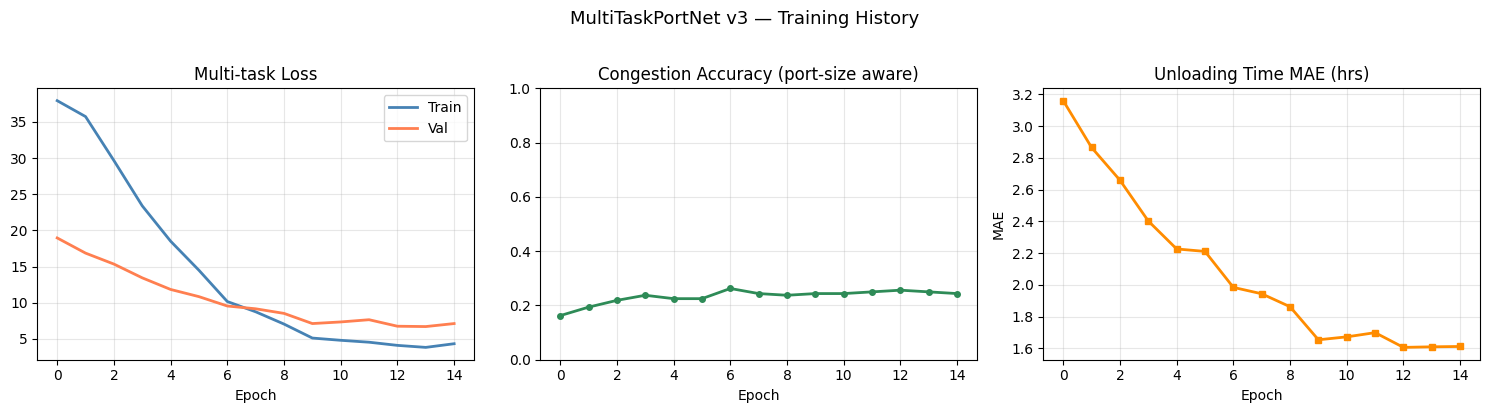

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train', color='steelblue', lw=2)
axes[0].plot(history['val_loss'],   label='Val',   color='coral',     lw=2)
axes[0].set_title('Multi-task Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['val_acc'], color='seagreen', lw=2, marker='o', ms=4)
axes[1].set_title('Congestion Accuracy (port-size aware)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylim(0,1); axes[1].grid(alpha=0.3)

axes[2].plot(history['val_mae'], color='darkorange', lw=2, marker='s', ms=4)
axes[2].set_title('Unloading Time MAE (hrs)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('MAE'); axes[2].grid(alpha=0.3)

plt.suptitle('MultiTaskPortNet v3 — Training History', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

CONGESTION CLASSIFICATION (imbalance-corrected)
                  precision    recall  f1-score   support

   Level 0 (Low)       0.84      0.58      0.69       102
Level 1 (Medium)       0.24      0.27      0.25        33
  Level 2 (High)       0.35      0.72      0.47        25

        accuracy                           0.54       160
       macro avg       0.48      0.52      0.47       160
    weighted avg       0.64      0.54      0.56       160

UNLOADING TIME REGRESSION
  MAE  : 1.898 hrs
  RMSE : 2.900 hrs
  R²   : -0.061


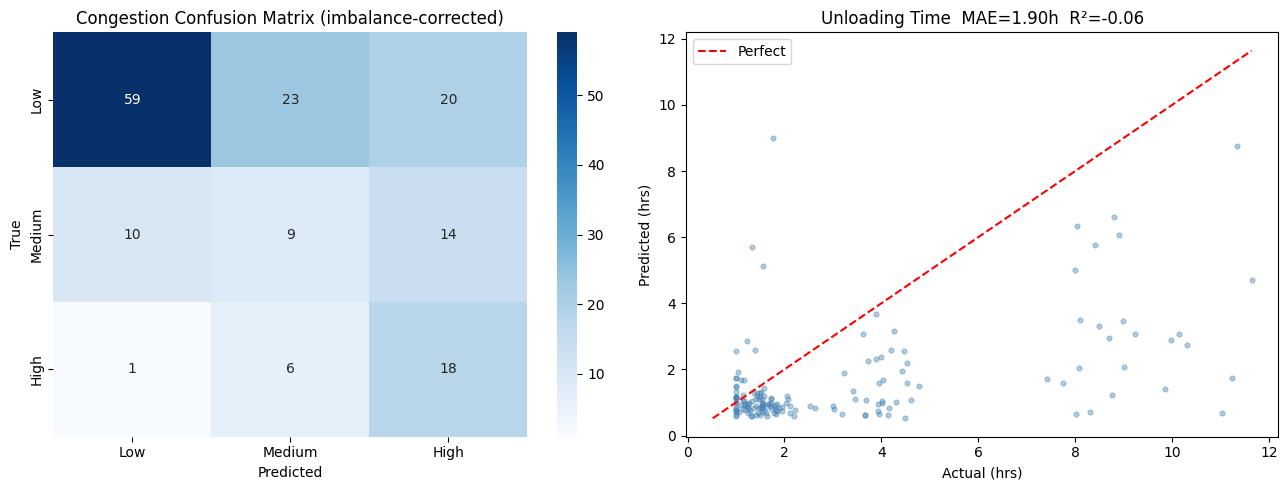

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
net.load_state_dict(torch.load(MODEL_PATH))
net.eval()

all_tc, all_pc, all_tt, all_pt = [], [], [], []

with torch.no_grad():
    for imgs, cap, cong, time_ in val_loader:
        imgs  = imgs.to(DEVICE)
        cap   = cap.to(DEVICE)
        logits, pred_t = net(imgs, cap)
        all_tc.extend(cong.numpy())
        all_pc.extend(logits.argmax(1).cpu().numpy())
        all_tt.extend(time_.numpy())
        all_pt.extend(pred_t.squeeze(1).cpu().numpy())

# Classification report
print('=' * 55)
print('CONGESTION CLASSIFICATION (imbalance-corrected)')
print('=' * 55)
print(classification_report(
    all_tc, all_pc,
    target_names=[f'Level {i} ({LEVEL_NAMES[i]})' for i in range(N_CLUSTERS)]
))

mae  = mean_absolute_error(all_tt, all_pt)
rmse = root_mean_squared_error(all_tt, all_pt)
r2   = r2_score(all_tt, all_pt)
print('=' * 55)
print('UNLOADING TIME REGRESSION')
print('=' * 55)
print(f'  MAE  : {mae:.3f} hrs')
print(f'  RMSE : {rmse:.3f} hrs')
print(f'  R²   : {r2:.3f}')

# Confusion matrix + regression scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(all_tc, all_pc)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=LEVEL_NAMES, yticklabels=LEVEL_NAMES)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Congestion Confusion Matrix (imbalance-corrected)')

axes[1].scatter(all_tt, all_pt, alpha=0.4, s=12, c='steelblue')
lim = [min(all_tt + all_pt), max(all_tt + all_pt)]
axes[1].plot(lim, lim, 'r--', lw=1.5, label='Perfect')
axes[1].set_xlabel('Actual (hrs)'); axes[1].set_ylabel('Predicted (hrs)')
axes[1].set_title(f'Unloading Time  MAE={mae:.2f}h  R²={r2:.2f}')
axes[1].legend()
plt.tight_layout(); plt.show()


In [38]:
torch.save({
    'epoch'                : EPOCHS,
    'model_state_dict'     : net.state_dict(),
    'optimizer_state_dict' : optimizer.state_dict(),
    'history'              : history,
    'kmeans_centers'       : kmeans.cluster_centers_,
    'cluster_remap'        : remap,
    'n_clusters'           : N_CLUSTERS,
    'congestion_overhead'  : CONGESTION_OVERHEAD,
    'capacity_divisor'     : CAPACITY_DIVISOR,
}, CKPT_PATH)

print(f'✅ Checkpoint saved → {CKPT_PATH}')

✅ Checkpoint saved → /kaggle/working/checkpoint.pth
